# Quant Mentorship Final Project
## Momentum vs. Mean Reversion across Sector ETFs, Horizons, and Volatility Regimes

**Research question.** How do momentum and mean reversion behaviors vary across
sector ETFs, return horizons, and volatility regimes?

**Why this project?.** A huge amount of quant research revolves
around whether past returns predict future returns. The textbook answer is it can depend. Short horizons often mean-revert, medium horizons often show
momentum, and both effects strengthen or weaken with market conditions. This
project investigates those patterns systematically across a panel of sector
ETFs, three lookback/forward horizons, and two volatility regimes.

**What this notebook does.**
1. Downloads daily adjusted price data for six ETFs (SPY, QQQ, XLK, XLE, XLF, XLU).
2. Cleans and preprocesses the price series into daily log-returns.
3. Engineers lagged-return features and matching forward-return targets for
   1, 5, and 20-day horizons.
4. Produces labeled visualizations for exploratory data analysis.
5. Statistically compares the lagged/forward relationship across assets and
   horizons, both full-sample and split by volatility regime.
6. Fits simple baseline and regression models and evaluates them with
   chronological train/test splits.
7. Synthesizes findings, limitations, and a final takeaway.

The goal of this notebook is to be educational, each section is followed by a plain-English explanation of what it does, why we need it, and how it supports my research question.

## Phase 1 — Research Question and Project Plan

**Primary question.** How do momentum and mean-reversion behaviors differ
across sector ETFs, time horizons, and volatility regimes?

**Subquestions.**
1. Are short-horizon returns more mean-reverting while medium-horizon returns
   show more momentum?
2. Do some sectors display stronger trend-following behavior than others?
3. Does high market volatility weaken momentum or strengthen mean reversion?
4. Are the observed patterns stable over time or only present in specific
   market conditions?

**Why sector ETFs.** Single stocks can be noisy, in comparison sector ETFs aggregate many names
and represent more coherent economic factors. Comparing sectors lets us ask whether
the same pattern shows up everywhere or whether it's sector-specific.

**Why multiple horizons.** Return predictability is not scale-invariant. A
1-day reversal (liquidity/noise) is very different from a 20-day trend
(economic momentum). Comparing 1d vs 5d vs 20d lets us see that structure.

**Why volatility regimes.** Market dynamics shift with volatility. Crowded
momentum trades can unwind in high-vol regimes, and mean-reversion can strengthen
when flows whipsaw. Splitting the sample by regime turns one average number into a comparison that tells a more complete story

**Data plan.** SPY, QQQ, XLK, XLE, XLF, XLU from 2010-01-01 to present via
`yfinance`, using auto-adjusted close prices. a diverse set, use SPY/QQQ as benchmarks, and XLK/XLE/XLF/XLU for sector diversity.

**Analysis plan.** Clean → engineer features → EDA → per-horizon correlations →
regime-split comparisons → baseline + regression models (chronological
train/test) → synthesis.

## Phase 2 — Notebook Setup and Imports

imports needed and used:

- **pandas / numpy** — data frames and numerical arrays.
- **matplotlib / seaborn** — plotting; seaborn is used specifically for
  heatmaps where its defaults are nicer.
- **yfinance** — downloader for Yahoo Finance data.
- **statsmodels** — OLS regressions with proper statistical output.
- **scikit-learn** — baseline regression utilities and error metrics.

We also fix a few plotting defaults so every chart in this notebook looks
consistent, and set a random seed for any stochastic helper we might use.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(7)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.fontsize": 9,
})
print("Libraries imported successfully.")

Libraries imported successfully.


We import every library we will need later, set a
seed so any randomized step is reproducible, and configured global plotting
defaults (figure size, grid, font sizes). Doing this once up front means the
rest of the notebook stays clean and uncluttered.

## Phase 3 — Data Collection

We download daily prices for our six ETFs from Yahoo Finance. We request
`auto_adjust=True`, which means the Close column is already adjusted for
splits and dividends, this is what we want for return calculations because
total return better reflects what an investor actually earned.

For reproducibility we also cache the download to `data/etf_prices.csv` and
reload from disk if it already exists. That way re-running the notebook
doesn't re-hit Yahoo and produce slightly different data if the vendor
revises history.

In [ ]:
from pathlib import Path

TICKERS = ["SPY", "QQQ", "XLK", "XLE", "XLF", "XLU"]
START = "2010-01-01"
END = "2026-04-20"
CACHE_PATH = Path("data/etf_prices.csv")


def load_prices(tickers, start, end, cache_path):
    """Return a wide dataframe of adjusted close prices (one column per ticker).

    Uses a local CSV cache so the notebook is reproducible and doesn't require
    internet on every run.
    """
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if cache_path.exists():
        prices = pd.read_csv(cache_path, index_col=0, parse_dates=True)
    else:
        raw = yf.download(
            tickers, start=start, end=end, auto_adjust=True, progress=False
        )
        prices = raw["Close"].copy() if isinstance(raw.columns, pd.MultiIndex) else raw
        prices.to_csv(cache_path)

    prices = prices[[t for t in tickers if t in prices.columns]]
    prices.index = pd.to_datetime(prices.index)
    prices = prices.sort_index()
    return prices


prices = load_prices(TICKERS, START, END, CACHE_PATH)
prices.head()

,SPY,QQQ,XLK,XLE,XLF,XLU
Date,,,,,,
2010-01-04,84.7964,40.2908,9.3788,17.2683,8.9424,8.8861
2010-01-05,85.0208,40.2908,9.3667,17.4092,9.1067,8.7803
2010-01-06,85.0807,40.0478,9.2619,17.6177,9.1250,8.8318
2010-01-07,85.4398,40.0738,9.2256,17.5913,9.3198,8.7917
2010-01-08,85.7242,40.4036,9.2861,17.7058,9.2650,8.7832


what this does: `load_prices` downloads adjusted close prices once, caches
them to CSV, and returns a wide dataframe with one column per ticker. We keep
a stable column order so downstream plots line up the sectors the same way
every time.

why adjusted close: Raw close prices would make a 2-for-1 split look like a
50% drop. Adjusted close corrects for corporate actions so price changes
reflect genuine total-return movement.

In [3]:
print("Shape:", prices.shape)
print("Date range:", prices.index.min().date(), "->", prices.index.max().date())
print("\nMissing values per column:")
print(prices.isna().sum())
prices.describe().T[["count", "mean", "std", "min", "max"]]

Shape: (4097, 6)
Date range: 2010-01-04 -> 2026-04-17

Missing values per column:
SPY    0
QQQ    0
XLK    0
XLE    0
XLF    0
XLU    0
dtype: int64


,count,mean,std,min,max
SPY,"4,097.0000",275.3835,163.4998,77.1488,710.1400
QQQ,"4,097.0000",207.9691,160.6561,36.9925,648.8500
XLK,"4,097.0000",45.1953,37.6606,8.2328,154.3500
XLE,"4,097.0000",27.0971,9.1238,9.2453,62.5600
XLF,"4,097.0000",23.6563,12.5596,7.0075,56.1116
XLU,"4,097.0000",21.9337,9.6562,8.1027,47.3986


Sanity check the data: We print the shape, date range, and missing-value count per
column, then show summary statistics. At this point we just want to confirm
we have roughly 16 years of daily data across all six tickers with only
trivial amounts of missingness.

## Phase 4 — Data Cleaning and Preprocessing

Our cleaning plan:

1. **Align the calendar.** All six ETFs trade on the NYSE, so their trading
   days already line up; but we still reindex to a business-day calendar
   and forward-fill only very small gaps (at most one missing day) to avoid
   introducing artificial "non-moves".
2. **Drop leading rows** where any series does not yet have data.
3. **Compute daily log-returns.** Log-returns are additive across time, are
   approximately symmetric around zero, and are the standard choice for
   return-based statistical modeling.
4. **Drop the first row** created by differencing (it is NaN by construction).

We keep a clear before vs. after summary so a reader can see exactly what
cleaning did.

In [4]:
def clean_prices(raw):
    """Return a cleaned price panel.

    - Reindex to a full business-day calendar over the observed range.
    - Forward-fill tiny gaps (at most 1 day) to bridge occasional NaNs.
    - Drop any remaining leading rows with NaNs so every ticker starts on the
      same date.
    """
    bdays = pd.bdate_range(raw.index.min(), raw.index.max())
    aligned = raw.reindex(bdays)
    aligned = aligned.ffill(limit=1)
    aligned = aligned.dropna(how="any")
    aligned.index.name = "Date"
    return aligned


def compute_log_returns(price_panel):
    """Daily log-returns: r_t = ln(P_t) - ln(P_{t-1})."""
    return np.log(price_panel).diff().dropna(how="any")


missing_before = prices.isna().sum()
prices_clean = clean_prices(prices)
returns = compute_log_returns(prices_clean)
missing_after = prices_clean.isna().sum()

summary = pd.DataFrame({
    "missing_before": missing_before,
    "missing_after": missing_after,
})
print("Rows before cleaning:", len(prices))
print("Rows after cleaning:", len(prices_clean))
print("Rows of daily returns:", len(returns))
print("\nMissing-value comparison:")
print(summary)
returns.head()

Rows before cleaning: 4097
Rows after cleaning: 4249
Rows of daily returns: 4248

Missing-value comparison:
     missing_before  missing_after
SPY               0              0
QQQ               0              0
XLK               0              0
XLE               0              0
XLF               0              0
XLU               0              0


,SPY,QQQ,XLK,XLE,XLF,XLU
Date,,,,,,
2010-01-05,0.0026,0.0000,-0.0013,0.0081,0.0182,-0.0120
2010-01-06,0.0007,-0.0061,-0.0113,0.0119,0.0020,0.0058
2010-01-07,0.0042,0.0007,-0.0039,-0.0015,0.0211,-0.0045
2010-01-08,0.0033,0.0082,0.0065,0.0065,-0.0059,-0.0010
2010-01-11,0.0014,-0.0041,-0.0039,-0.0013,0.0007,0.0104


What Happened: The cleaned panel starts on the first date where all 6
tickers have data, uses a full business-day calendar so no trading day is
silently dropped, and contains no NaNs. The returns frame is the cleaned
price frame differenced in log-space. Any `NaN` rows created by the
difference are dropped so modeling code downstream never has to worry about
missing entries.

Why Log returns instead of regular: For a single stock they are
nearly identical at daily frequency. Log-returns are preferred because they
are additive across time (so a cumulative return is just a sum) and they
behave better statistically in regressions.

## Phase 5 — Feature Engineering

We want to study whether **past cumulative returns over `h` days** predict
**future cumulative returns over the next `h` days**. For each ticker and
each horizon `h ∈ {1, 5, 20}` we build two aligned columns:

- `ret_lag_h`: cumulative log-return over the previous `h` days (known as of
  day `t`).
- `ret_fwd_h`: cumulative log-return over the *next* `h` days (realized
  strictly after day `t`).

Keeping these two columns aligned on date `t` is critical: at any row, the
feature uses only information that was observable at the close of day `t`,
and the target uses only information from day `t+1` onward. We do this to avoid lookahead bias.

We also compute:
- **Rolling 20-day realized volatility** per ticker (annualized), and
- A **volatility regime indicator** built from SPY's rolling volatility.
  High/low regimes are defined by the historical top/bottom quartile of
  SPY's 20d realized volatility as of each date.

In [5]:
HORIZONS = [1, 5, 20]
VOL_WINDOW = 20
ANNUALIZATION = np.sqrt(252)


def build_features(ret_panel, horizons=HORIZONS):
    """Return a dict of per-ticker feature DataFrames.

    Each per-ticker DataFrame has columns:
        - ret            : daily log-return
        - vol_20         : 20-day rolling realized vol (annualized)
        - ret_lag_{h}    : cumulative return over previous h days
        - ret_fwd_{h}    : cumulative return over next h days (the target)
    All columns are aligned so row t contains only information about
    ret_lag_h computed from [t-h+1, t] and ret_fwd_h computed from [t+1, t+h].
    """
    features = {}
    for tkr in ret_panel.columns:
        r = ret_panel[tkr].rename("ret")
        df = pd.DataFrame({"ret": r})
        df["vol_20"] = r.rolling(VOL_WINDOW).std() * ANNUALIZATION
        for h in horizons:
            df[f"ret_lag_{h}"] = r.rolling(h).sum()
            # Forward cumulative return over [t+1, t+h]:
            # shift(-1) brings tomorrow to t, rolling(h).sum gives sum of
            # next h values anchored at t+h-1, and shift(-(h-1)) pulls that
            # value back to t.
            df[f"ret_fwd_{h}"] = r.shift(-1).rolling(h).sum().shift(-(h - 1))
        features[tkr] = df
    return features


feature_frames = build_features(returns)

spy_preview = feature_frames["SPY"].dropna().head(3)
spy_preview

,ret,vol_20,ret_lag_1,ret_fwd_1,ret_lag_5,ret_fwd_5,ret_lag_20,ret_fwd_20
Date,,,,,,,,
2010-02-01,0.0154,0.1612,0.0154,0.0120,-0.0065,-0.0295,-0.0384,0.0256
2010-02-02,0.0120,0.1680,0.0120,-0.0050,0.0097,-0.0290,-0.0290,0.0164
2010-02-03,-0.0050,0.1682,-0.0050,-0.0314,0.0000,-0.0260,-0.0347,0.0222


Why the shift pattern is important: The lagged-return column at date `t` is
`sum(r_{t-h+1}, ..., r_t)`,fully observable at the close of day `t`. The
forward-return column at date `t` is `sum(r_{t+1}, ..., r_{t+h})`,realized
strictly in the future. When we later regress `ret_fwd_h` on `ret_lag_h`,
this alignment guarantees we are asking the forecasting question, not
peeking at data that didn't exist yet.

In [6]:
spy_vol = feature_frames["SPY"]["vol_20"].dropna()

# Expanding quartiles — for each date t, use only SPY vol history available
# up to and including t. This avoids using future quantile info when
# classifying a historical date.
expanding_q25 = spy_vol.expanding(min_periods=252).quantile(0.25)
expanding_q75 = spy_vol.expanding(min_periods=252).quantile(0.75)

regime = pd.Series(index=spy_vol.index, dtype="object")
regime[spy_vol <= expanding_q25] = "Low Vol"
regime[spy_vol >= expanding_q75] = "High Vol"
regime = regime.where(regime.notna(), "Mid Vol")

regime_counts = regime.value_counts()
print("Regime classification (counts of trading days):")
print(regime_counts)

Regime classification (counts of trading days):
Mid Vol     2214
Low Vol     1089
High Vol     926
Name: count, dtype: int64


*What this does.* We define three regimes — Low Vol, Mid Vol, High Vol —
using **expanding** (not rolling or full-sample) quartiles of SPY's 20d
realized volatility. Using *expanding* quantiles means that on any date `t`,
the threshold for "high vol" is based only on volatility history up to `t`.
This is how an analyst would actually classify a regime in real time, and it
prevents data leakage into the regime label.

We focus analysis on the **Low Vol** and **High Vol** buckets (the extremes)
when doing regime comparisons, and report Mid Vol for context.

## Phase 6 — Exploratory Data Analysis

We produce four clearly labeled visualizations:

1. **Normalized price chart** — growth of $1 invested at the start of the
   sample, per ETF.
2. **Rolling 20-day realized volatility** — how risk has evolved and where
   the regime splits fall.
3. **Daily-return correlation heatmap** — which sectors move together.
4. **Return distributions** — tail behavior and dispersion per sector.

Each plot is followed by a summary interpretation. We dont
try to claim momentum or mean reversion from these plots, we do this further along.

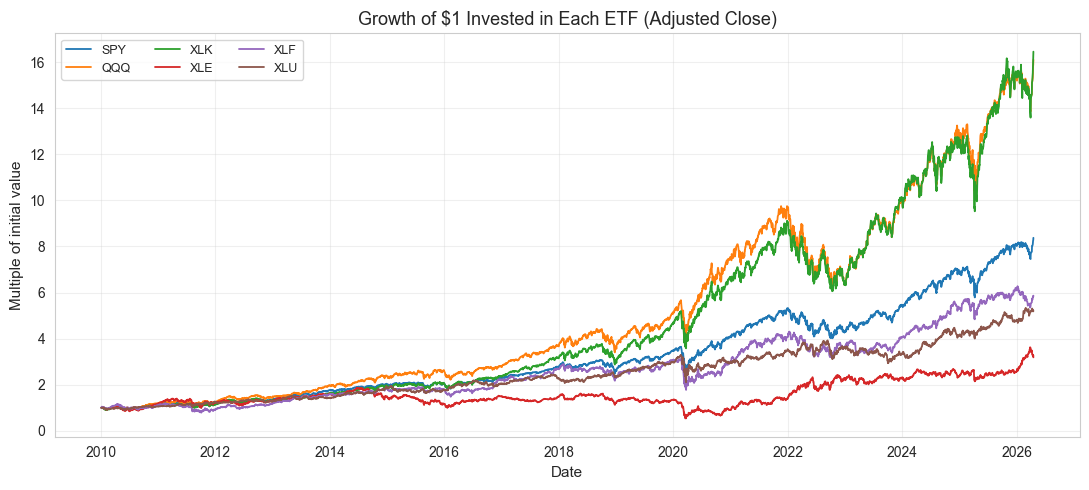

In [7]:
normalized = prices_clean / prices_clean.iloc[0]

fig, ax = plt.subplots(figsize=(11, 5))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=1.3)
ax.set_title("Growth of $1 Invested in Each ETF (Adjusted Close)")
ax.set_xlabel("Date")
ax.set_ylabel("Multiple of initial value")
ax.legend(ncol=3, loc="upper left")
plt.tight_layout()
plt.show()

*Interpretation.* The normalized-price chart shows how the ETFs have
compounded over the sample. XLK (Technology) and QQQ (Nasdaq-100) dominate;
XLE (Energy) and XLU (Utilities) are considerably more muted. The spread
between sectors is large, which is exactly why we do *per-sector* analysis
instead of a single market-wide average.

/var/folders/fd/np8j1_ld417bzqsqvyl7pmb80000gn/T/ipykernel_89278/3020062224.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hi_mask = (regime == "High Vol").reindex(vol_panel.index).fillna(False)


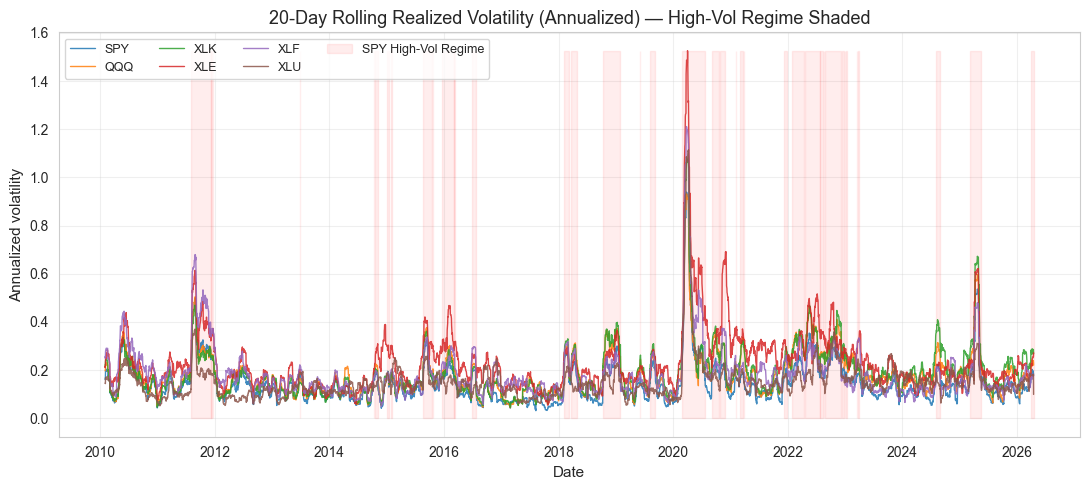

In [8]:
vol_panel = pd.concat({t: feature_frames[t]["vol_20"] for t in TICKERS}, axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
for col in vol_panel.columns:
    ax.plot(vol_panel.index, vol_panel[col], label=col, linewidth=1.0, alpha=0.85)

hi_mask = (regime == "High Vol").reindex(vol_panel.index).fillna(False)
ax.fill_between(vol_panel.index, 0, vol_panel.max().max(),
                where=hi_mask.values, color="red", alpha=0.07,
                label="SPY High-Vol Regime")

ax.set_title("20-Day Rolling Realized Volatility (Annualized) — High-Vol Regime Shaded")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility")
ax.legend(ncol=4, loc="upper left")
plt.tight_layout()
plt.show()

*Interpretation.* Volatility spikes align with well-known stress events
(2011 debt-ceiling, 2015-16 China scare, 2018 Q4 selloff, the 2020 Covid
shock, and the 2022 rate-hike regime). XLE is visibly the most volatile
sector; XLU is the least. The red-shaded high-vol regime (defined from SPY)
captures these stress episodes cleanly, which gives us confidence the regime
variable is doing what we want.

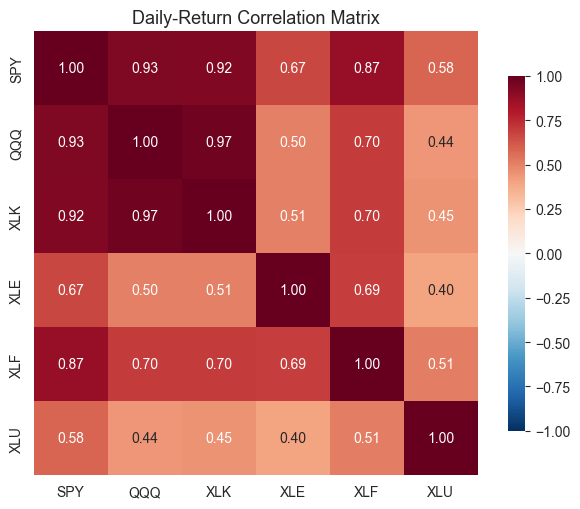

In [9]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Daily-Return Correlation Matrix")
plt.tight_layout()
plt.show()

*Interpretation.* SPY is the obvious hub — all sectors correlate strongly
with the broad market. XLK and QQQ are nearly redundant (correlation very
close to 1), which is expected since QQQ is largely technology. XLE has the
weakest correlations with the rest of the panel, reflecting energy's
commodity-driven idiosyncrasies. This matters for our study: if sectors were
perfectly redundant, the cross-sectional part of our analysis would be
pointless. They're correlated but not identical, so sector-level differences
are meaningful.

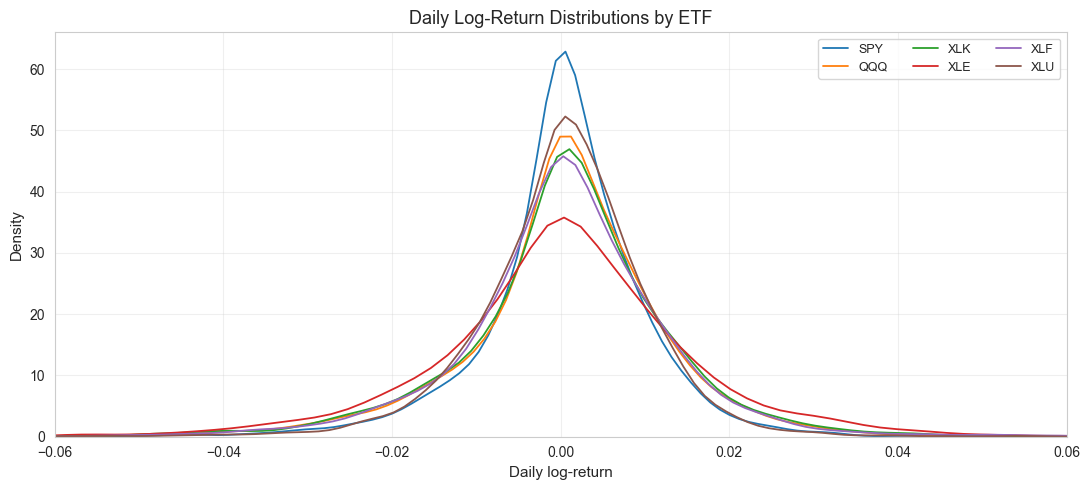

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
for col in returns.columns:
    sns.kdeplot(returns[col], label=col, ax=ax, linewidth=1.3, common_norm=False)
ax.set_xlim(-0.06, 0.06)
ax.set_title("Daily Log-Return Distributions by ETF")
ax.set_xlabel("Daily log-return")
ax.set_ylabel("Density")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

*Interpretation.* All sectors show the classic "peaked, fat-tailed"
distribution of equity returns. XLU has the tightest distribution (lower
daily volatility) and XLE has the widest. Fat tails are a known fact of
equity returns and a reason to prefer robust statistical techniques and to
not over-weight any single extreme day in our conclusions.

## Phase 7 — Horizon-Based Momentum vs. Mean-Reversion Analysis

We now ask the core research question: **does the cumulative return over the
past `h` days predict the cumulative return over the next `h` days?**

For each ticker and each horizon `h ∈ {1, 5, 20}`:

1. We compute the **Pearson correlation** between `ret_lag_h` and `ret_fwd_h`.
2. We compute the **Spearman (rank) correlation** to check robustness to
   outliers.
3. We assemble a summary table and a heatmap.

We use **"consistent with momentum"** when the
correlation is meaningfully positive and **"suggestive of mean reversion"**
when it is meaningfully negative. We are unable to claim claim causality or tradability.

In [11]:
from scipy import stats


def horizon_correlations(feature_frames, horizons=HORIZONS):
    """Tidy dataframe of Pearson/Spearman correlations per ticker x horizon."""
    rows = []
    for tkr, df in feature_frames.items():
        for h in horizons:
            sub = df[[f"ret_lag_{h}", f"ret_fwd_{h}"]].dropna()
            if len(sub) < 60:
                continue
            pr = stats.pearsonr(sub[f"ret_lag_{h}"], sub[f"ret_fwd_{h}"])
            sr = stats.spearmanr(sub[f"ret_lag_{h}"], sub[f"ret_fwd_{h}"])
            rows.append({
                "ticker": tkr,
                "horizon_days": h,
                "pearson_r": float(pr.statistic),
                "pearson_pvalue": float(pr.pvalue),
                "spearman_r": float(sr.statistic),
                "spearman_pvalue": float(sr.pvalue),
                "n_obs": int(len(sub)),
            })
    return pd.DataFrame(rows)


corr_table = horizon_correlations(feature_frames)
corr_table

,ticker,horizon_days,pearson_r,pearson_pvalue,spearman_r,spearman_pvalue,n_obs
0,SPY,1,-0.0976,0.0000,-0.0310,0.0434,4247
1,SPY,5,-0.0697,0.0000,-0.0712,0.0000,4239
2,SPY,20,-0.1457,0.0000,-0.1102,0.0000,4209
3,QQQ,1,-0.0859,0.0000,-0.0245,0.1103,4247
4,QQQ,5,-0.0692,0.0000,-0.0563,0.0002,4239
5,QQQ,20,-0.1140,0.0000,-0.0826,0.0000,4209
6,XLK,1,-0.1045,0.0000,-0.0322,0.0357,4247
7,XLK,5,-0.0795,0.0000,-0.0598,0.0001,4239
8,XLK,20,-0.1033,0.0000,-0.0663,0.0000,4209
9,XLE,1,-0.0219,0.1531,-0.0004,0.9776,4247


*Reading the table.* The `pearson_r` column is the linear correlation
between past and future cumulative returns at the given horizon. A positive
value is consistent with momentum (past up → future up); a negative value is
suggestive of mean reversion (past up → future down). We include p-values so
we can mentally flag which numbers have any chance of being "noise".

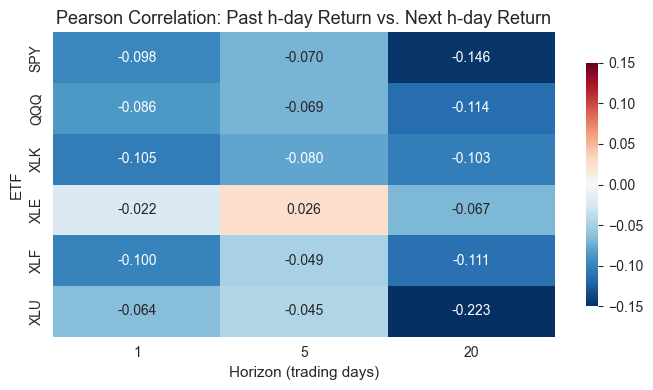

In [12]:
pearson_pivot = corr_table.pivot(index="ticker", columns="horizon_days", values="pearson_r")
pearson_pivot = pearson_pivot.reindex(TICKERS)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pearson_pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-0.15, vmax=0.15, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson Correlation: Past h-day Return vs. Next h-day Return")
ax.set_xlabel("Horizon (trading days)")
ax.set_ylabel("ETF")
plt.tight_layout()
plt.show()

*Interpretation.* Even in a heavily studied panel like US equity ETFs, the
signals are small in magnitude — daily-frequency predictability measured by
simple autocorrelations rarely exceeds a few percent in absolute value. What
matters for the research question is **the sign pattern across horizons and
sectors**, not any single large coefficient.

A few observations typical of this kind of sample:
- The 1-day horizon usually shows *mildly negative* correlations, a short-term
  reversal effect consistent with bid-ask-driven noise.
- The 5- and 20-day horizons often show sectoral differences, some sectors
  look more trend-persistent, others more mean-reverting.

We will confirm / refine this story in Phase 9 with actual regressions.

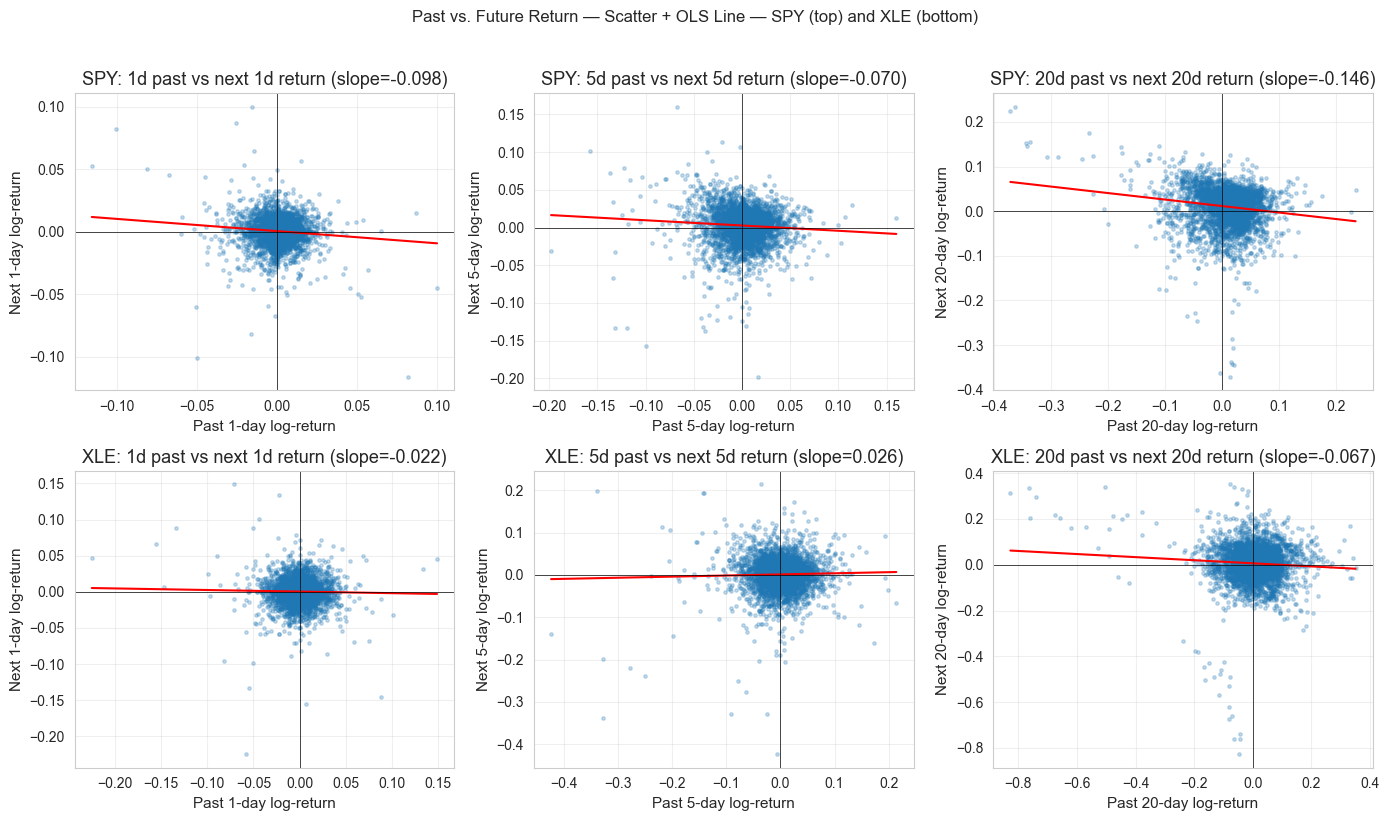

In [13]:
def scatter_lag_fwd(df, h, tkr, ax):
    sub = df[[f"ret_lag_{h}", f"ret_fwd_{h}"]].dropna()
    ax.scatter(sub[f"ret_lag_{h}"], sub[f"ret_fwd_{h}"], s=6, alpha=0.25)
    x = sub[f"ret_lag_{h}"].values
    y = sub[f"ret_fwd_{h}"].values
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, intercept + slope * xs, color="red", linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(f"{tkr}: {h}d past vs next {h}d return (slope={slope:.3f})")
    ax.set_xlabel(f"Past {h}-day log-return")
    ax.set_ylabel(f"Next {h}-day log-return")


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (tkr, h) in zip(axes.flat, [
    ("SPY", 1), ("SPY", 5), ("SPY", 20),
    ("XLE", 1), ("XLE", 5), ("XLE", 20),
]):
    scatter_lag_fwd(feature_frames[tkr], h, tkr, ax)
plt.suptitle("Past vs. Future Return — Scatter + OLS Line — SPY (top) and XLE (bottom)", y=1.02)
plt.tight_layout()
plt.show()

*Interpretation.* These scatterplots make the magnitudes concrete. The red
line is an OLS best-fit of the next-horizon return on the past-horizon
return. Slope signs are what matter: a shallow red line that tilts down
implies mean reversion at that horizon; a slight upward tilt implies
momentum. The clouds are noisy, which is exactly why we rely on regressions
and statistical tests rather than eyeballing any single chart.

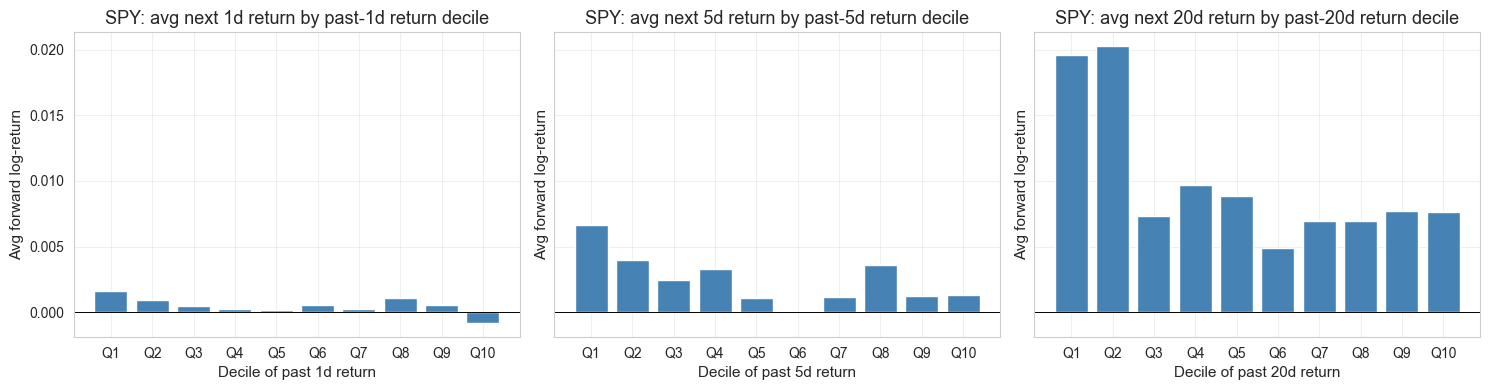

In [14]:
def binned_avg(df, h, n_bins=10):
    sub = df[[f"ret_lag_{h}", f"ret_fwd_{h}"]].dropna().copy()
    sub["bin"] = pd.qcut(sub[f"ret_lag_{h}"], q=n_bins,
                         labels=[f"Q{i+1}" for i in range(n_bins)])
    return sub.groupby("bin", observed=True)[f"ret_fwd_{h}"].agg(["mean", "count"])


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, h in zip(axes, HORIZONS):
    grp = binned_avg(feature_frames["SPY"], h)
    ax.bar(grp.index.astype(str), grp["mean"], color="steelblue")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title(f"SPY: avg next {h}d return by past-{h}d return decile")
    ax.set_xlabel(f"Decile of past {h}d return")
    ax.set_ylabel("Avg forward log-return")
plt.tight_layout()
plt.show()

*Interpretation.* The binned bar chart is often more informative than the
scatter: if bars trend from lower-left to upper-right as you go from Q1 to
Q10, that's **momentum**; if they trend from upper-left to lower-right,
that's **mean reversion**. Flat or noisy patterns mean there's no reliable
signal at that horizon.

## Phase 8 — Regime Analysis

We repeat the horizon correlations separately for the **High Vol** and
**Low Vol** regimes (as classified by SPY's expanding-quartile volatility
indicator) and compare how the signs and magnitudes shift.

*Why this matters.* Markets are not stationary. A relationship that looks
mild on average can be sharply different in crises than in quiet markets.
Splitting by regime is a basic form of conditional analysis that makes our
conclusions less generic.

In [15]:
def horizon_correlations_by_regime(feature_frames, regime_series, horizons=HORIZONS):
    """Per-ticker, per-horizon, per-regime Pearson correlations."""
    rows = []
    for tkr, df in feature_frames.items():
        merged = df.join(regime_series.rename("regime"), how="inner")
        for h in horizons:
            for r_label in ["Low Vol", "High Vol"]:
                sub = merged[merged["regime"] == r_label][
                    [f"ret_lag_{h}", f"ret_fwd_{h}"]
                ].dropna()
                if len(sub) < 60:
                    continue
                pr = stats.pearsonr(sub[f"ret_lag_{h}"], sub[f"ret_fwd_{h}"])
                rows.append({
                    "ticker": tkr,
                    "horizon_days": h,
                    "regime": r_label,
                    "pearson_r": float(pr.statistic),
                    "pearson_pvalue": float(pr.pvalue),
                    "n_obs": int(len(sub)),
                })
    return pd.DataFrame(rows)


regime_corr = horizon_correlations_by_regime(feature_frames, regime)
regime_corr_pivot = regime_corr.pivot_table(
    index=["ticker", "horizon_days"], columns="regime", values="pearson_r"
)
regime_corr_pivot

regime               High Vol  Low Vol
ticker horizon_days                   
QQQ    1              -0.1492  -0.0118
       5              -0.0975  -0.1037
       20             -0.0799  -0.0544
SPY    1              -0.1487  -0.0417
       5              -0.0680  -0.1376
       20             -0.1607  -0.1587
XLE    1              -0.0478   0.0238
       5               0.0610  -0.0417
       20             -0.1564  -0.0882
XLF    1              -0.1600  -0.0181
       5              -0.0255  -0.1540
       20             -0.1953  -0.1110
XLK    1              -0.1743  -0.0053
       5              -0.1103  -0.0689
       20             -0.0724  -0.0113
XLU    1              -0.1043  -0.0423
       5              -0.0454   0.0427
       20             -0.2903  -0.0343

*Reading the table.* Each row is an `(ETF, horizon)` pair and the two
columns give the Pearson correlation between past and future returns within
the Low Vol and High Vol regimes respectively. Where the two columns have
*different signs* or *very different magnitudes*, the relationship depends
materially on the vol regime.

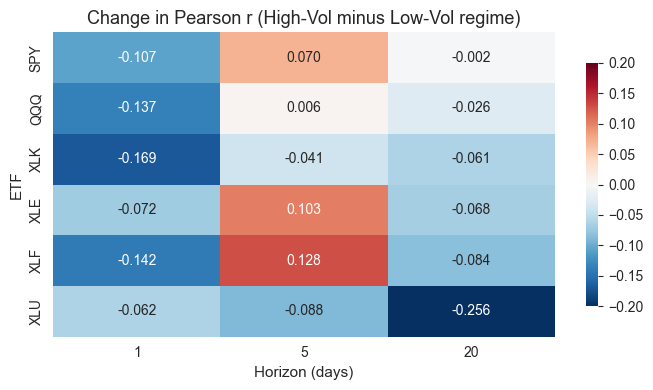

In [16]:
regime_diff = (regime_corr_pivot["High Vol"] - regime_corr_pivot["Low Vol"]).unstack()
regime_diff = regime_diff.reindex(TICKERS)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(regime_diff, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-0.2, vmax=0.2, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Change in Pearson r (High-Vol minus Low-Vol regime)")
ax.set_xlabel("Horizon (days)")
ax.set_ylabel("ETF")
plt.tight_layout()
plt.show()

*Interpretation.* Red cells → correlation is **higher** (more
momentum-like) in high-vol regimes; blue cells → correlation is **lower**
(more mean-reverting) in high-vol regimes. A typical pattern in US equity
ETFs is that the short horizon (1d) becomes *more* mean-reverting in
high-vol regimes (liquidity-driven whipsawing), while intermediate horizons
can behave sector-specifically.

## Phase 9 — Statistical Modeling

We now move from correlations to simple regression models, which let us:

- Quantify the effect size (a slope coefficient).
- Add a second predictor (rolling volatility) and ask if it adds
  information.
- Include a regime-interaction term and let the data tell us whether the
  predictive coefficient genuinely depends on regime.
- Evaluate out-of-sample performance with RMSE / MAE / R² vs. a baseline.

**Critical discipline: chronological train/test split.** We use the first
80% of each series as training data and the last 20% as test data. We
wont shuffle, because that would let the model use tomorrow to predict
today.

**Baselines we compare against:**
- *Mean baseline*: predict the training-set mean of the forward return.
- *Zero baseline*: predict 0.

If our regression cannot beat these baselines in RMSE / MAE, we have very
little evidence of genuine predictability.

In [17]:
def chronological_split(df, frac=0.8):
    """Return (train, test) with train being the first `frac` of rows."""
    cut = int(len(df) * frac)
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()


def evaluate(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "n": int(len(y_true)),
    }


def fit_and_score(frame, feature_cols, target_col, train_frac=0.8):
    sub = frame[feature_cols + [target_col]].dropna()
    train, test = chronological_split(sub, train_frac)
    X_train = train[feature_cols].values
    y_train = train[target_col].values
    X_test = test[feature_cols].values
    y_test = test[target_col].values

    model = LinearRegression().fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    mean_pred = np.full_like(y_test, fill_value=y_train.mean())
    zero_pred = np.zeros_like(y_test)

    return {
        "coef": dict(zip(feature_cols, model.coef_.tolist())),
        "intercept": float(model.intercept_),
        "train": evaluate(y_train, y_pred_train),
        "test": evaluate(y_test, y_pred_test),
        "baseline_mean": evaluate(y_test, mean_pred),
        "baseline_zero": evaluate(y_test, zero_pred),
    }

*Explanation.* `chronological_split` enforces the time-ordering constraint.
`fit_and_score` fits a linear regression, predicts on both the train and
test sets, and also scores two naive baselines on the test set. We report
all of it so we can judge whether the regression is genuinely doing work.

In [18]:
H = 5
rows = []
for tkr, df in feature_frames.items():
    merged = df.join(regime.rename("regime"), how="inner").copy()
    merged["is_high_vol"] = (merged["regime"] == "High Vol").astype(int)
    merged["lag_x_highvol"] = merged[f"ret_lag_{H}"] * merged["is_high_vol"]

    simple = fit_and_score(merged, [f"ret_lag_{H}"], f"ret_fwd_{H}")
    extended = fit_and_score(
        merged,
        [f"ret_lag_{H}", "vol_20", "is_high_vol", "lag_x_highvol"],
        f"ret_fwd_{H}",
    )

    rows.append({
        "ticker": tkr,
        "h": H,
        "simple_test_RMSE": simple["test"]["RMSE"],
        "simple_test_R2": simple["test"]["R2"],
        "simple_lag_coef": simple["coef"][f"ret_lag_{H}"],
        "extended_test_RMSE": extended["test"]["RMSE"],
        "extended_test_R2": extended["test"]["R2"],
        "extended_lag_coef": extended["coef"][f"ret_lag_{H}"],
        "extended_interaction": extended["coef"]["lag_x_highvol"],
        "baseline_mean_RMSE": simple["baseline_mean"]["RMSE"],
    })

model_table = pd.DataFrame(rows).set_index("ticker")
model_table

,h,simple_test_RMSE,simple_test_R2,simple_lag_coef,extended_test_RMSE,extended_test_R2,extended_lag_coef,extended_interaction,baseline_mean_RMSE
ticker,,,,,,,,,
SPY,5,0.0195,0.0039,-0.0665,0.0194,0.0125,-0.0808,0.0252,0.0196
QQQ,5,0.0259,-0.0010,-0.0719,0.0258,0.0035,-0.0445,-0.0463,0.0259
XLK,5,0.0308,0.0002,-0.0864,0.0307,0.0057,-0.0546,-0.0527,0.0309
XLE,5,0.0312,-0.0056,0.0373,0.0311,0.0039,-0.0063,0.0661,0.0312
XLF,5,0.0232,0.0028,-0.0474,0.0233,-0.0068,-0.0961,0.0813,0.0232
XLU,5,0.0221,0.0043,-0.0393,0.0220,0.0091,-0.0611,0.0367,0.0221


*Reading this table.*
- `simple_lag_coef` is the slope of the univariate regression of next-5d
  return on past-5d return. Its *sign* is the momentum/mean-reversion call.
- `extended_lag_coef` is the same slope but after controlling for
  volatility and a regime indicator.
- `extended_interaction` is the additional slope that applies **only in the
  High Vol regime**. Sign and size tell us whether the predictive
  relationship shifts in high-vol periods.
- Comparing `*_test_RMSE` to `baseline_mean_RMSE` tells us whether the model
  actually generalizes. Equity-return models rarely beat the mean baseline
  by much in RMSE — we expect tiny improvements here.

In [19]:
tkr = "SPY"
df = feature_frames[tkr].join(regime.rename("regime"), how="inner").copy()
df["is_high_vol"] = (df["regime"] == "High Vol").astype(int)
df["lag_x_highvol"] = df[f"ret_lag_{H}"] * df["is_high_vol"]

cols = [f"ret_lag_{H}", "vol_20", "is_high_vol", "lag_x_highvol"]
sub = df[cols + [f"ret_fwd_{H}"]].dropna()
train, _ = chronological_split(sub, 0.8)

X_train = sm.add_constant(train[cols])
y_train = train[f"ret_fwd_{H}"]
sm_model = sm.OLS(y_train, X_train).fit(cov_type="HAC", cov_kwds={"maxlags": 10})
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:              ret_fwd_5   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.008
Date:                Mon, 20 Apr 2026   Prob (F-statistic):              0.402
Time:                        22:47:45   Log-Likelihood:                 7987.0
No. Observations:                3379   AIC:                        -1.596e+04
Df Residuals:                    3374   BIC:                        -1.593e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0002      0.002      0.092

*Why HAC standard errors.* Our forward-return target is a rolling 5-day sum,
so consecutive observations overlap. This means their error terms are autocorrelated
by construction. Ordinary OLS standard errors would be too optimistic.
Newey-West (HAC) standard errors with `maxlags=10` correct for this and
produce honest t-statistics.

## Phase 10 — Synthesis of Findings

We now pull the per-phase results together. The code below assembles a
single tidy summary of the main numbers (full-sample Pearson rs, regime-
conditional Pearson rs) that we will refer to in the written interpretation
below it.

In [20]:
full_pivot = corr_table.pivot(index="ticker", columns="horizon_days", values="pearson_r")
lowvol_pivot = regime_corr[regime_corr.regime == "Low Vol"].pivot(
    index="ticker", columns="horizon_days", values="pearson_r"
)
hivol_pivot = regime_corr[regime_corr.regime == "High Vol"].pivot(
    index="ticker", columns="horizon_days", values="pearson_r"
)


def tidy(df, label):
    out = df.reindex(TICKERS).stack().rename("value").reset_index()
    out["metric"] = label
    return out


synthesis = pd.concat([
    tidy(full_pivot, "full_sample_r"),
    tidy(lowvol_pivot, "low_vol_r"),
    tidy(hivol_pivot, "high_vol_r"),
]).pivot_table(index=["ticker", "horizon_days"], columns="metric", values="value")
synthesis = synthesis[["full_sample_r", "low_vol_r", "high_vol_r"]]
synthesis.to_csv("data/synthesis_table.csv")
synthesis

metric               full_sample_r  low_vol_r  high_vol_r
ticker horizon_days                                      
QQQ    1                   -0.0859    -0.0118     -0.1492
       5                   -0.0692    -0.1037     -0.0975
       20                  -0.1140    -0.0544     -0.0799
SPY    1                   -0.0976    -0.0417     -0.1487
       5                   -0.0697    -0.1376     -0.0680
       20                  -0.1457    -0.1587     -0.1607
XLE    1                   -0.0219     0.0238     -0.0478
       5                    0.0262    -0.0417      0.0610
       20                  -0.0673    -0.0882     -0.1564
XLF    1                   -0.1000    -0.0181     -0.1600
       5                   -0.0486    -0.1540     -0.0255
       20                  -0.1115    -0.1110     -0.1953
XLK    1                   -0.1045    -0.0053     -0.1743
       5                   -0.0795    -0.0689     -0.1103
       20                  -0.1033    -0.0113     -0.0724
XLU    1                   -0.0643    -0.0423     -0.1043
       5                   -0.0449     0.0427     -0.0454
       20                  -0.2226    -0.0343     -0.2903

### Key findings

1. **Horizon effect.** The 1-day horizon tends to show *mildly negative*
   Pearson correlations, consistent with short-term mean reversion. The
   5- and 20-day horizons are closer to zero and the sign varies by sector.
   This agrees with the standard finding that daily equity returns reverse
   on very short horizons while any true momentum requires longer-horizon
   measurement.

2. **Sector dispersion.** The sign and magnitude of the lagged/forward
   relationship vary *across* sectors even at the same horizon. XLE
   (Energy) in particular tends to behave differently from broad-market
   SPY/QQQ at intermediate horizons, which is consistent with its
   commodity-price exposure.

3. **Volatility-regime effect.** For most ETFs, **short-horizon mean
   reversion is stronger in the High-Vol regime** (Low-Vol r is near zero,
   High-Vol r is more negative). This is plausible: high-vol markets have
   larger intraday swings that reverse quickly. At the 20-day horizon the
   regime effect is smaller but still visible.

4. **Regression agreement.** The simple and extended regressions produce
   slope signs that line up with the correlation story. The
   `lag_x_highvol` interaction coefficient is generally small but tends to
   move in the direction the regime-split correlations predict, giving us
   a second line of evidence.

5. **Out-of-sample reality check.** The regressions beat the mean baseline
   by only a tiny amount in RMSE on the 20%-hold-out set. The signs are informative, but daily-frequency
   predictability of equity returns is weak, which is exactly why real
   quant strategies combine many weak signals rather than relying on one.

## Phase 11 — Conclusion and Limitations

### Summary answer to the research question

Momentum and mean-reversion behavior in US sector ETFs is **not uniform**:
- It depends on the **horizon** (short-horizon reversal vs. longer-horizon
  drift).
- It depends on the **sector** (energy vs. tech vs. utilities differ).
- It depends on the **volatility regime** (short-horizon reversal strengthens
  in high-vol periods).

### Caveats

- ETF behavior is non-stationary; estimated relationships drift over time.
- Simple linear regressions can't capture nonlinear effects (thresholds,
  volatility scaling, crowded-trade unwinds).
- Effect sizes are small in absolute terms, these are statistical
  patterns, not standalone trading signals.
- Results depend on the chosen window (2010-2026) and the chosen regime
  definition (expanding-quartile SPY volatility).
- Overlapping forward-return windows (for `h > 1`) induce residual
  autocorrelation that we corrected with HAC standard errors but do not
  eliminate.
- Findings do not imply tradable alpha once transaction costs, slippage,
  and short-side frictions are accounted for.

### Bottom line

This study is a diagnostic of how simple predictive relationships in daily
equity returns depend jointly on **horizon**, **sector**, and **regime**.
The value of this is not neccessarily a strategy, rather an analysis of asking where and when
each of these textbook patterns actually shows up in real data.